In [2]:
# skipped hyperparameter chapter
# at last?


Image
- Image is nothing
but a matrix of numbers. The computer cannot see the images as humans do. It only
looks at numbers, and that’s what the images are. A grayscale image is a two-
dimensional matrix with values ranging from 0 to 255. 0 is black, 255 is white and
in between you have all shades of grey.
-  Previously, when there was no deep learning
(or when deep learning was not popular), people used to look at pixels. Each pixel
was a feature. You can do this easily in Python. Just read the grayscale image using
OpenCV or Python-PIL, convert to a numpy array and ravel (flatten) the matrix. If
you are dealing with RGB images, then you have three matrices instead of one.
- Pixel in camera used to measure the intensity of light in numeric(check )

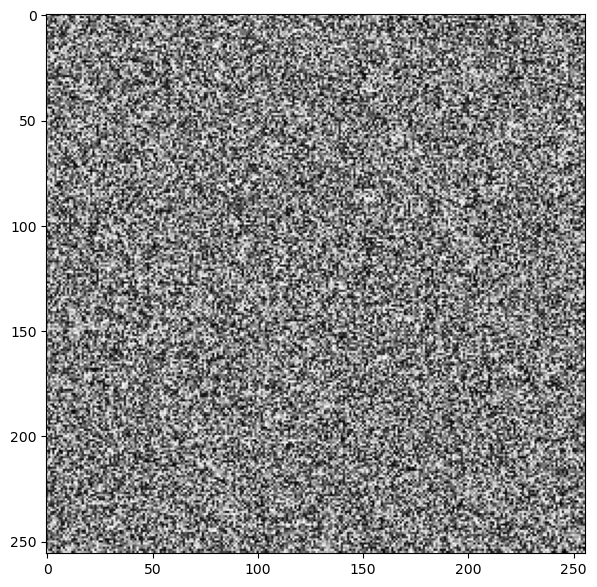

In [5]:
import numpy as np
import matplotlib.pyplot as plt
# generate random numpy array with values from 0 to 255
# and a size of 256x256
random_image = np.random.randint(0, 256, (256, 256))
# initialize plot
plt.figure(figsize=(7, 7))
# show grayscale image, nb: cmap, vmin and vmax
plt.imshow(random_image, cmap='gray', vmin=0, vmax=255)
plt.show()
# The code above generates a random matrix using numpy. This matrix consists of
# values ranging from 0 to 255 (included) and is of size 256x256 (also known as
# pixels).

#### 2-D image array (single channel) and its ravelled version
- As you can see that the ravelled version is nothing but a vector of size M, where M
= N * N. In this case, this vector is of the size 256 * 256 = 65536.
- Now, if we go ahead and do it for all the images in our dataset, we have 65536
features for each sample. We can now quickly build a decision tree model or
random forest or SVM-based model on this data. The models will look at pixel
values and would try to separate positive samples from negative samples (in case
of a binary classification problem).

In [6]:
random_image

array([[216, 229,  59, ...,   7, 224, 217],
       [122, 117, 106, ...,  81, 230, 223],
       [ 45, 152,  33, ..., 178, 236, 112],
       ...,
       [ 77, 190,  57, ...,   7,  48,   0],
       [236,  53,   8, ...,  74, 227,  42],
       [212, 220, 166, ..., 220,  92, 217]])

In [9]:
# Ravelled (flattened) version
ravelled_image = random_image.ravel()
print("Original shape:", random_image.shape)
print("Ravelled shape:", ravelled_image.shape)

Original shape: (256, 256)
Ravelled shape: (65536,)


#### Building a model to detect if an X-ray image of a lung has pneumothorax or not.

In [1]:
import os
import pandas as pd
import numpy as np

from PIL import Image
from sklearn import metrics
from sklearn import ensemble
from sklearn import model_selection

from tqdm import tqdm

In [2]:
import os
os.getcwd()

'/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml'

In [12]:
import pandas as pd


# initally steup for data in repo ,not required later
import pandas as pd
df = pd.read_csv("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/stage_2_train.csv")  # instead of siim_png/train-rle.csv
df["target"] = (~df["EncodedPixels"].isna()).astype(int)
df.rename(columns={"ImageId": "ImageId"}, inplace=True)
# df = df[["ImageId", "target"]]
# df.to_csv("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train.csv", index=False)
print(df.head())


   Unnamed: 0                                            ImageId  \
0         420  1.2.276.0.7230010.3.1.4.8323329.3678.151787517...   
1        9772  1.2.276.0.7230010.3.1.4.8323329.4200.151787518...   
2        1542  1.2.276.0.7230010.3.1.4.8323329.4862.151787518...   
3        7532  1.2.276.0.7230010.3.1.4.8323329.12313.15178752...   
4        5542  1.2.276.0.7230010.3.1.4.8323329.14214.15178752...   

                                       EncodedPixels  target  
0  194329 37 960 69 919 111 913 117 910 116 912 5...       1  
1                                                 -1       1  
2  344265 2 1020 7 1015 9 1012 12 1010 14 1008 15...       1  
3                                                 -1       1  
4                                                 -1       1  


In [35]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn import ensemble
from sklearn import metrics
from sklearn import model_selection
from tqdm import tqdm
def create_dataset(training_df, image_dir):
    """
    This function takes the training dataframe
    and outputs training array and labels
    :param training_df: dataframe with ImageId, Target columns
    :param image_dir: location of images (folder), string
    :return: X, y (training array with features and labels)
    """
    # create empty list to store image vectors
    images = []
    # create empty list to store targets
    targets = []
    # loop over the dataframe
    for index, row in tqdm(training_df.iterrows(),total=len(training_df),desc="processing images"):
        # get image id
        image_id = row["ImageId"]
        # create image path
        image_path = os.path.join(image_dir, image_id)
        # open image using PIL
        image = Image.open(image_path + ".png")
        # resize image to 256x256. we use bilinear resampling
        image = image.resize((256, 256), resample=Image.BILINEAR)
        # convert image to array
        image = np.array(image)
        # ravel
        image = image.ravel()
        # append images and targets lists
        images.append(image)
        targets.append(int(row["target"]))
    # convert list of list of images to numpy array
    images = np.array(images)
    # print size of this array
    print(images.shape)
    return images, targets
# Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train_png/ID_0a0adf93f.png
    
if __name__ == "__main__":
    csv_path = "/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train_new.csv"
    image_path = "/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train_png/"
    # read CSV with imageid and target columns
    df = pd.read_csv(csv_path)
    # we create a new column called kfold and fill it with -1
    df["kfold"] = -1
    # the next step is to randomize the rows of the data
    df = df.sample(frac=1).reset_index(drop=True)
    # fetch labels
    y = df.target.values
    # initiate the kfold class from model_selection module
    kf = model_selection.StratifiedKFold(n_splits=5)
    # fill the new kfold column
    for f, (t_, v_) in enumerate(kf.split(X=df, y=y)):
        df.loc[v_, 'kfold'] = f
    # we go over the folds created
    for fold_ in range(3):
        # temporary dataframes for train and test
        train_df = df[df.kfold != fold_].reset_index(drop=True)
        test_df = df[df.kfold == fold_].reset_index(drop=True)
        # create train dataset
        # you can move this outside to save some computation time
        xtrain, ytrain = create_dataset(train_df, image_path)
        # create test dataset
        # you can move this outside to save some computation time
        xtest, ytest = create_dataset(test_df, image_path)
        # fit random forest without any modification of params
        clf = ensemble.RandomForestClassifier(n_jobs=-1)
        clf.fit(xtrain, ytrain)
        # predict probability of class 1
        preds = clf.predict_proba(xtest)[:, 1]
        # print results
        print(f"FOLD: {fold_}")
        print(f"AUC = {metrics.roc_auc_score(ytest, preds)}")
        print("")

processing images: 100%|████████████████████| 2564/2564 [00:26<00:00, 98.12it/s]


(2564, 65536)


processing images: 100%|██████████████████████| 641/641 [00:06<00:00, 96.85it/s]


(641, 65536)


IndexError: index 1 is out of bounds for axis 1 with size 1

In [ ]:
csv_path = "/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train_new.csv"

In [25]:

import os, pandas as pd
pngs = [f for f in os.listdir("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train_png/") if f.endswith(".png")]
df = pd.DataFrame({"ImageId":[f.replace(".png","") for f in pngs], "target":0})
# df.to_csv("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train_new.csv", index=False)


In [20]:
df=pd.read_csv(csv_path)

In [26]:
df.target.unique()

array(['target'], dtype=object)

In [30]:
import pandas as pd
df = pd.read_csv("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/stage_2_train.csv")  # instead of siim_png/train-rle.csv
df["target"] = (~df["EncodedPixels"].isna()).astype(int)
# df.rename(columns={"ImageId": "ImageId"}, inplace=True)
# # df = df[["ImageId", "target"]]
# # df.to_csv("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train.csv", index=False)
# print(df.head())


In [31]:
df

,Unnamed: 0,ImageId,EncodedPixels,target
0,420,1.2.276.0.7230010.3.1.4.8323329.3678.151787517...,194329 37 960 69 919 111 913 117 910 116 912 5...,1
1,9772,1.2.276.0.7230010.3.1.4.8323329.4200.151787518...,-1,1
2,1542,1.2.276.0.7230010.3.1.4.8323329.4862.151787518...,344265 2 1020 7 1015 9 1012 12 1010 14 1008 15...,1
3,7532,1.2.276.0.7230010.3.1.4.8323329.12313.15178752...,-1,1
4,5542,1.2.276.0.7230010.3.1.4.8323329.14214.15178752...,-1,1
...,...,...,...,...
12949,9837,1.2.276.0.7230010.3.1.4.8323329.3554.151787517...,-1,1
12950,4353,1.2.276.0.7230010.3.1.4.8323329.10366.15178752...,514175 10 1008 29 994 30 993 32 991 33 990 34 ...,1
12951,6020,1.2.276.0.7230010.3.1.4.8323329.1280.151787516...,-1,1
12952,1565,1.2.276.0.7230010.3.1.4.8323329.5454.151787518...,-1,1


In [32]:
from pathlib import Path
import pydicom, shutil

dcm_dir = Path("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/stage_2_images")     # has ID_*.dcm
id_png_dir = Path("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train_png")       # has ID_*.png
uid_png_dir = Path("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/uid_png")        # will hold <UID>.png
uid_png_dir.mkdir(parents=True, exist_ok=True)

# map UID -> ID (stem without extension)
uid_to_id = {}
for dcm_path in dcm_dir.rglob("*.dcm"):
    d = pydicom.dcmread(dcm_path, stop_before_pixels=True)
    uid = str(d.SOPInstanceUID)
    uid_to_id[uid] = dcm_path.stem   # e.g. ID_0a0adf93f

# create <UID>.png by copying (or symlinking) from existing ID_*.png
missing = 0
for uid, id_stem in uid_to_id.items():
    src = id_png_dir / f"{id_stem}.png"
    dst = uid_png_dir / f"{uid}.png"
    if src.exists():
        # use symlink on UNIX; fall back to copy on Windows
        try:
            dst.unlink(missing_ok=True)
            dst.symlink_to(src)
        except Exception:
            shutil.copy2(src, dst)
    else:
        missing += 1

print("PNG made by UID. Missing from ID set:", missing)


/Users/akhichoudhary/miniconda3/envs/ml/lib/python3.10/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_5fc3e24ab'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/Users/akhichoudhary/miniconda3/envs/ml/lib/python3.10/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_c045fd9aa'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/Users/akhichoudhary/miniconda3/envs/ml/lib/python3.10/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_ec3d4bba8'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/Users/akhichoudhary/miniconda3/envs/ml/lib/python3.10/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid val

PNG made by UID. Missing from ID set: 0


In [33]:
from pathlib import Path
import pydicom, shutil

dcm_dir = Path("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/stage_2_images")     # has ID_*.dcm
id_png_dir = Path("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train_png")       # has ID_*.png
uid_png_dir = Path("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/uid_png")        # will hold <UID>.png
uid_png_dir.mkdir(parents=True, exist_ok=True)

uid_png_dir.mkdir(parents=True, exist_ok=True)

for dcm_path in dcm_dir.glob("ID_*.dcm"):
    ds = pydicom.dcmread(dcm_path, stop_before_pixels=True)
    uid = str(ds.SOPInstanceUID)
    id_png = id_png_dir / f"{dcm_path.stem}.png"
    uid_png = uid_png_dir / f"{uid}.png"
    if id_png.exists():
        if uid_png.exists():
            uid_png.unlink()
        # copy; or use symlink on Unix: uid_png.symlink_to(id_png)
        shutil.copy2(id_png, uid_png)


In [36]:
from pathlib import Path
import pandas as pd

csv_path = "/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train_new.csv"
uid_png_dir=Path("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/uid_png/")  
# uid_png_dir = Path("/.../siim_png/uid_png")

df = pd.read_csv(csv_path)
df["png"] = df["ImageId"].astype(str) + ".png"
exists = df["png"].apply(lambda f: (uid_png_dir / f).exists())
print("Matched images:", exists.sum(), "/", len(df))
print("Targets:", df.loc[exists, "target"].value_counts().to_dict())


Matched images: 3205 / 3205
Targets: {0: 3205}


In [37]:
import pandas as pd
from pathlib import Path

# 1) Load the official stage_2_train.csv (has ImageId, EncodedPixels)
stage_csv = "/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/stage_2_train.csv"   # <-- change to your actual path
df_raw = pd.read_csv(stage_csv)

# 2) Normalize a boolean flag “has_mask” on each row
#    - Kaggle positives have a non-null RLE; some dumps also use "-1" for no mask
has_mask = (~df_raw["EncodedPixels"].isna()) & (df_raw["EncodedPixels"].astype(str) != "-1")
df_raw["has_mask"] = has_mask.astype(int)

# 3) Aggregate to one row per ImageId: target = 1 if any row has a mask
df_img = (
    df_raw.groupby("ImageId", as_index=False)["has_mask"]
          .max()
          .rename(columns={"has_mask": "target"})
)

# 4) (Optional) sanity check label balance
print("Targets balance:", df_img["target"].value_counts().to_dict())

# 5) Save this clean image-level file
clean_csv = "/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train_image_level.csv"   # <-- your choice
df_img.to_csv(clean_csv, index=False)
print("Wrote:", clean_csv)

# 6) Verify that your UID-named PNGs exist for these ImageIds
uid_png_dir = Path("/PATH/siim_png/uid_png")  # folder with <SOPInstanceUID>.png
df_img["png"] = df_img["ImageId"].astype(str) + ".png"
exists = df_img["png"].apply(lambda f: (uid_png_dir/f).exists())
print("Matched images:", exists.sum(), "/", len(df_img))

# Keep only rows that actually have a PNG
df_img = df_img[exists].reset_index(drop=True)
print("Targets after filtering:", df_img["target"].value_counts().to_dict())


Targets balance: {0: 9378, 1: 2669}
Wrote: /Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train_image_level.csv
Matched images: 0 / 12047
Targets after filtering: {}


In [42]:
import pandas as pd
df = pd.read_csv("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train_image_level.csv")  # instead of siim_png/train-rle.csv
# df["target"] = (~df["Enco÷dedPixels"].isna()).astype(int)
# df.rename(columns={"ImageId": "ImageId"}, inplace=True)
# # df = df[["ImageId", "target"]]
# # df.to_csv("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train.csv", index=False)
# print(df.head())


In [43]:
df

,ImageId,target
0,1.2.276.0.7230010.3.1.4.8323329.1000.151787516...,0
1,1.2.276.0.7230010.3.1.4.8323329.10000.15178752...,0
2,1.2.276.0.7230010.3.1.4.8323329.10001.15178752...,0
3,1.2.276.0.7230010.3.1.4.8323329.10002.15178752...,0
4,1.2.276.0.7230010.3.1.4.8323329.10003.15178752...,0
...,...,...
12042,1.2.276.0.7230010.3.1.4.8323329.7049.151787520...,0
12043,1.2.276.0.7230010.3.1.4.8323329.705.1517875164...,1
12044,1.2.276.0.7230010.3.1.4.8323329.7050.151787520...,0
12045,1.2.276.0.7230010.3.1.4.8323329.7051.151787520...,0


In [44]:
from pathlib import Path
import pandas as pd

csv_path = "/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train_image_level.csv"
uid_png_dir=Path("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/uid_png/")  
# uid_png_dir = Path("/.../siim_png/uid_png")

df = pd.read_csv(csv_path)
df["png"] = df["ImageId"].astype(str) + ".png"
exists = df["png"].apply(lambda f: (uid_png_dir / f).exists())
print("Matched images:", exists.sum(), "/", len(df))
print("Targets:", df.loc[exists, "target"].value_counts().to_dict())


Matched images: 0 / 12047
Targets: {}


In [47]:
# dicom_to_uid_png.py
import os
from pathlib import Path
import numpy as np
import pydicom
from pydicom.pixel_data_handlers.util import apply_modality_lut
from PIL import Image
from tqdm import tqdm

SRC = Path("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/stage_2_images")     # has ID_*.dcm
# id_png_dir = Path("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train_png")       # has ID_*.png
DST = Path("/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/uid_png1")        # will hold <UID>.png
# dicom_to_uid_png.py (robust UID extraction)
import os
from pathlib import Path
import numpy as np
import pydicom
from pydicom.pixel_data_handlers.util import apply_modality_lut
from PIL import Image
from tqdm import tqdm

# SRC = Path("siim_png/stage_2_images")   # DICOMs (ID_*.dcm in subfolders OK)
# DST = Path("siim_png/uid_png")          # will hold <SOPInstanceUID>.png
DST.mkdir(parents=True, exist_ok=True)

def is_plausible_uid(uid: str) -> bool:
    # SIIM UIDs are like "1.2.276...." -> digits & dots, startswith digit, contains dots
    if not isinstance(uid, str): return False
    if not uid or not uid[0].isdigit(): return False
    if "." not in uid: return False
    return all(part.isdigit() for part in uid.split("."))

def get_uid(ds) -> str | None:
    # Try main dataset
    uid = getattr(ds, "SOPInstanceUID", None)
    if is_plausible_uid(uid): return uid
    # Try file meta
    fm = getattr(ds, "file_meta", None)
    if fm is not None:
        uid2 = getattr(fm, "MediaStorageSOPInstanceUID", None)
        if is_plausible_uid(uid2): return uid2
    return None

def dcm_to_uint8(ds):
    arr = apply_modality_lut(ds.pixel_array, ds)
    if getattr(ds, "PhotometricInterpretation", "").upper() == "MONOCHROME1":
        arr = np.max(arr) - arr
    lo, hi = np.percentile(arr, [1, 99])
    if hi <= lo: lo, hi = float(arr.min()), float(arr.max())
    arr = np.clip(arr, lo, hi)
    arr = (arr - lo) / (hi - lo + 1e-6)
    return (arr * 255).astype(np.uint8)

def save_as_uid_png(dcm_path: Path):
    ds = pydicom.dcmread(str(dcm_path))  # don't use force=True unless needed
    uid = get_uid(ds)
    if uid is None:
        # As a last resort, skip this file (don’t save with "ID_*" which will break CSV join)
        raise ValueError(f"No plausible UID found (SOPInstanceUID or file_meta.MediaStorageSOPInstanceUID).")
    img = dcm_to_uint8(ds)
    Image.fromarray(img).save(DST / f"{uid}.png")

dcm_files = list(SRC.rglob("*.dcm"))
skipped = 0
for p in tqdm(dcm_files, desc="Converting DICOM→PNG by UID"):
    try:
        save_as_uid_png(p)
    except Exception as e:
        skipped += 1
        print(f"⚠️ Skipping {p.name}: {e}")

print(f"✅ Done. PNGs saved to: {DST}  |  Skipped: {skipped}")



Converting DICOM→PNG by UID: 100%|██████████| 3205/3205 [06:54<00:00,  7.74it/s]

✅ Done. PNGs saved to: /Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/uid_png1  |  Skipped: 0


In [51]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn import ensemble
from sklearn import metrics
from sklearn import model_selection
from tqdm import tqdm
def create_dataset(training_df, image_dir):
    """
    This function takes the training dataframe
    and outputs training array and labels
    :param training_df: dataframe with ImageId, Target columns
    :param image_dir: location of images (folder), string
    :return: X, y (training array with features and labels)
    """
    # create empty list to store image vectors
    images = []
    # create empty list to store targets
    targets = []
    # loop over the dataframe
    for index, row in tqdm(training_df.iterrows(),total=len(training_df),desc="processing images"):
        # get image id
        image_id = row["ImageId"]
        # create image path
        image_path = os.path.join(image_dir, image_id)
        # open image using PIL
        image = Image.open(image_path + ".png")
        # resize image to 256x256. we use bilinear resampling
        image = image.resize((256, 256), resample=Image.BILINEAR)
        # convert image to array
        image = np.array(image)
        # ravel
        image = image.ravel()
        # append images and targets lists
        images.append(image)
        targets.append(int(row["target"]))
    # convert list of list of images to numpy array
    images = np.array(images)
    # print size of this array
    print(images.shape)
    return images, targets
# Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train_png/ID_0a0adf93f.png
    
if __name__ == "__main__":
    csv_path = "/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/train_new.csv"
    image_path = "/Users/akhichoudhary/STATS/Thinkstats/Thinkstats2_exercise/Thinkstats/Approach any problem with ml/data/siim-acr-pneumothorax-segmentation/siim_png/uid_png1/"
    # read CSV with imageid and target columns
    df = pd.read_csv(csv_path)
    # we create a new column called kfold and fill it with -1
    df["kfold"] = -1
    # the next step is to randomize the rows of the data
    df = df.sample(frac=1).reset_index(drop=True)
    # fetch labels
    y = df.target.values
    # initiate the kfold class from model_selection module
    kf = model_selection.StratifiedKFold(n_splits=5)
    # fill the new kfold column
    for f, (t_, v_) in enumerate(kf.split(X=df, y=y)):
        df.loc[v_, 'kfold'] = f
    # we go over the folds created
    for fold_ in range(3):
        # temporary dataframes for train and test
        train_df = df[df.kfold != fold_].reset_index(drop=True)
        test_df = df[df.kfold == fold_].reset_index(drop=True)
        # create train dataset
        # you can move this outside to save some computation time
        xtrain, ytrain = create_dataset(train_df, image_path)
        # create test dataset
        # you can move this outside to save some computation time
        xtest, ytest = create_dataset(test_df, image_path)
        # fit random forest without any modification of params
        clf = ensemble.RandomForestClassifier(n_jobs=-1)
        clf.fit(xtrain, ytrain)
        # predict probability of class 1
        proba = clf.predict_proba(xtest)
        if proba.shape[1] == 1:
            # model saw only one class during fitting (shouldn’t happen with the guards, but just in case)
            print(f"⏭️  Skipping fold {fold_}: model has only one class in predict_proba")
            continue
        preds = proba[:, 1]
        preds = clf.predict_proba(xtest)[:, 1]
        # print results
        print(f"FOLD: {fold_}")
        print(f"AUC = {metrics.roc_auc_score(ytest, preds)}")
        print("")

processing images: 100%|████████████████████| 2564/2564 [00:27<00:00, 94.73it/s]


(2564, 65536)


processing images: 100%|██████████████████████| 641/641 [00:06<00:00, 92.14it/s]


(641, 65536)
⏭️  Skipping fold 0: model has only one class in predict_proba


processing images: 100%|████████████████████| 2564/2564 [00:26<00:00, 96.35it/s]


...

(641, 65536)
⏭️  Skipping fold 1: model has only one class in predict_proba


processing images: 100%|████████████████████| 2564/2564 [00:26<00:00, 96.22it/s]


(2564, 65536)


processing images: 100%|██████████████████████| 641/641 [00:06<00:00, 91.68it/s]


(641, 65536)
⏭️  Skipping fold 2: model has only one class in predict_proba


In [57]:
import torch.nn as nn
import pretrainedmodels

def get_model(pretrained):
    if pretrained:
        model=pretrainedmodels.__dict__['alexnet'](pretrained='imagenet')
    else:
        model=pretrainedmodels.__dict__['alexnet'](pretrained=None)


    model.last_linear=nn.Sequential(
        nn.BatchNorm1d(4096),
        nn.Dropout(p=0.25),
        nn.Linear(in_features=4096,out_features=2048),
        nn.ReLU(),
        nn.BatchNorm1d(2048,eps=1e-05,momentum=0.1),
        nn.Dropout(p=0.5),
        nn.Linear(in_features=2048,out_features=1),
    )
    return model

In [58]:
# !pip install  pretrainedmodels

In [59]:
print(get_model())

TypeError: get_model() missing 1 required positional argument: 'pretrained'